<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day4_ExerciseXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 : Data Import and Initial Exploration
In this section, we will import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# URL to the dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'

# Loading the dataset.
# Note: This dataset is semicolon separated and contains '?' for missing values.
df = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date', 'Time']},
                 infer_datetime_format=True, low_memory=False, na_values=['?'], index_col='datetime')

# Display the first few rows
display(df.head())

/tmp/ipykernel_1862/800901867.py:11: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/tmp/ipykernel_1862/800901867.py:11: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date', 'Time']},
/tmp/ipykernel_1862/800901867.py:11: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(url, sep=';', parse_dates={'datetime': ['Date', 'Time']},


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [2]:
# Check data types and shape
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (2075259, 7)

Data Types:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Summary Statistics:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


# Part 2 : Handling Missing Values
Identify and fill missing values using the mean of the respective columns.

In [3]:
# Identify columns with missing values
print("Missing values per column before filling:")
print(df.isnull().sum())

# Fill missing values with the mean of each column
df = df.fillna(df.mean())

# Verify that there are no more missing values
print("\nMissing values per column after filling:")
print(df.isnull().sum())

Missing values per column before filling:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values per column after filling:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


# Part 3 : Data Visualization
Resampling the data over a day to visualize trends in power consumption and intensity.

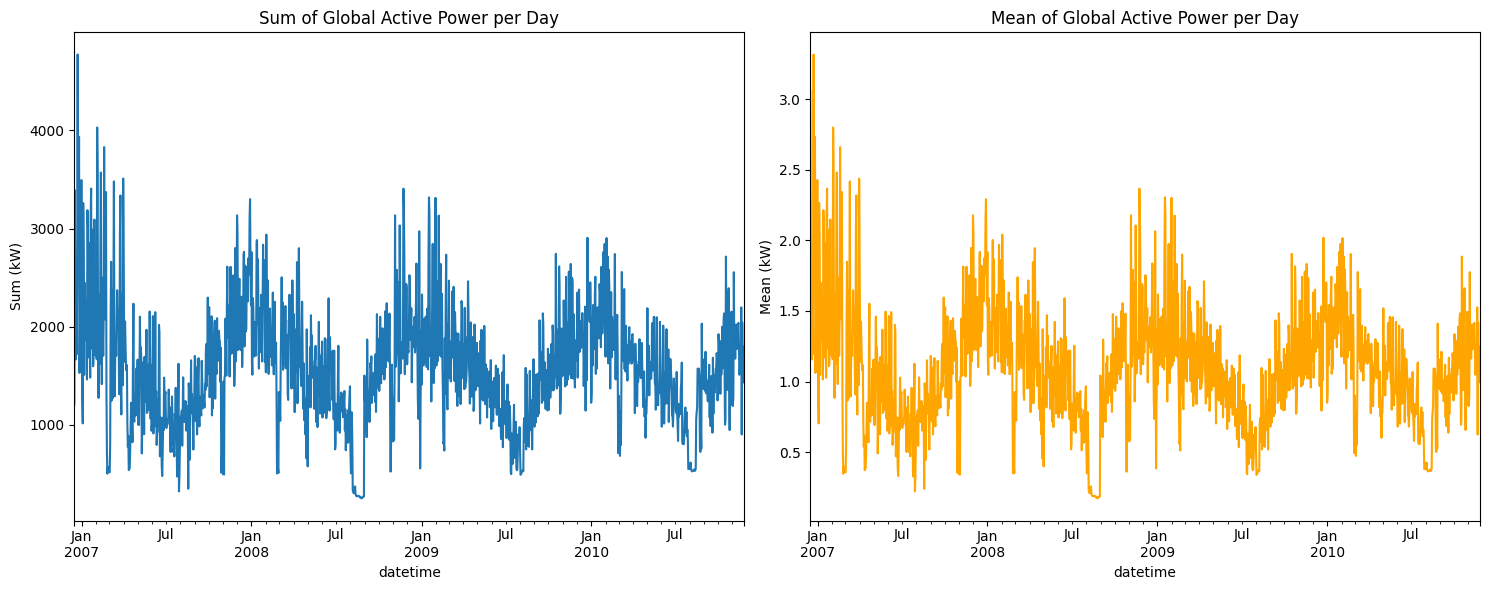

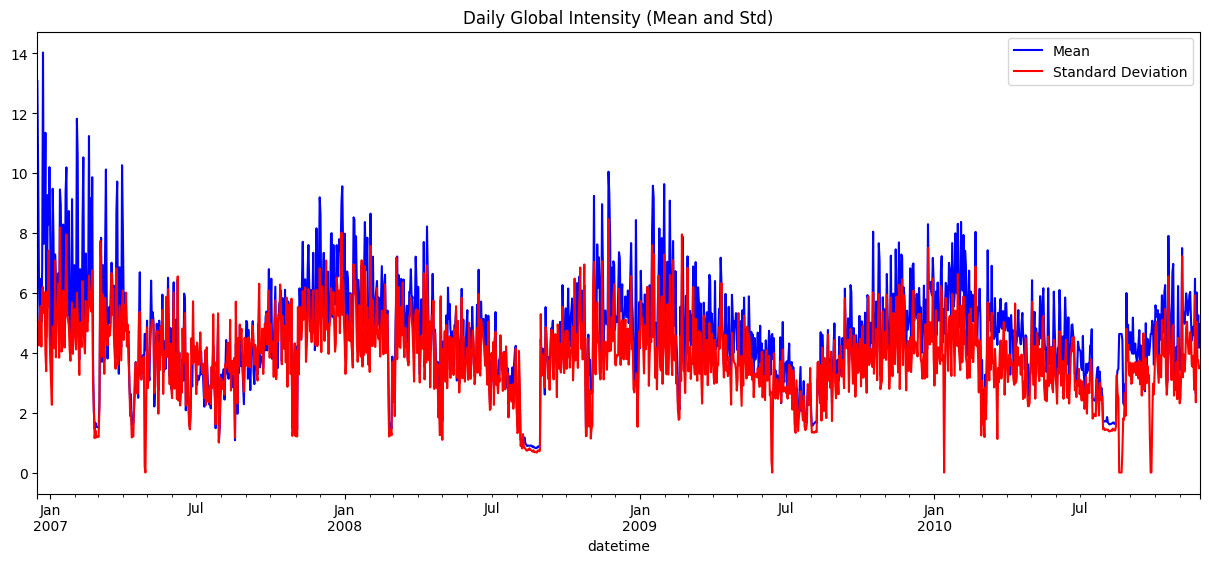

In [4]:
# Resample 'Global_active_power' over a day
daily_gap = df['Global_active_power'].resample('D')

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
daily_gap.sum().plot(title='Sum of Global Active Power per Day')
plt.ylabel('Sum (kW)')

plt.subplot(1, 2, 2)
daily_gap.mean().plot(title='Mean of Global Active Power per Day', color='orange')
plt.ylabel('Mean (kW)')
plt.tight_layout()
plt.show()

# Resample 'Global_intensity' over a day
daily_intensity = df['Global_intensity'].resample('D')

plt.figure(figsize=(15, 6))
daily_intensity.mean().plot(label='Mean', color='blue')
daily_intensity.std().plot(label='Standard Deviation', color='red')
plt.title('Daily Global Intensity (Mean and Std)')
plt.legend()
plt.show()

# Reorganizing... (Deleting duplicate Part 6)

In [5]:
# Cell duplicate removed. Please use the Part 6 at the bottom.

# Part 4 : Data Preprocessing for LSTM
Normalizing the data, splitting into train/test sets, and reshaping for LSTM input.

In [6]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# We will focus on 'Global_active_power' for this prediction task
values = df['Global_active_power'].values.reshape(-1, 1)

# Normalize the features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(values)

# Function to create sequences
def create_sequences(data, seq_length):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Create sequences (using last 60 minutes to predict the next minute)
sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Reshape X for LSTM [samples, time steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split into training and testing sets (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1660159, 60, 1)
X_test shape: (415040, 60, 1)


# Part 5 : Building an LSTM Model
Defining and compiling the LSTM architecture.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

# Part 6 : Training and Evaluating the LSTM Model
Training the model and plotting training/validation loss.

Epoch 1/5
23058/23058 ━━━━━━━━━━━━━━━━━━━━ 256s 11ms/step - loss: 7.9745e-04 - val_loss: 3.8005e-04
Epoch 2/5
23058/23058 ━━━━━━━━━━━━━━━━━━━━ 246s 11ms/step - loss: 6.8522e-04 - val_loss: 3.7235e-04
Epoch 3/5
23058/23058 ━━━━━━━━━━━━━━━━━━━━ 244s 11ms/step - loss: 6.6863e-04 - val_loss: 3.6979e-04
Epoch 4/5
23058/23058 ━━━━━━━━━━━━━━━━━━━━ 248s 11ms/step - loss: 6.5698e-04 - val_loss: 3.6737e-04
Epoch 5/5
23058/23058 ━━━━━━━━━━━━━━━━━━━━ 243s 11ms/step - loss: 6.4632e-04 - val_loss: 3.6153e-04


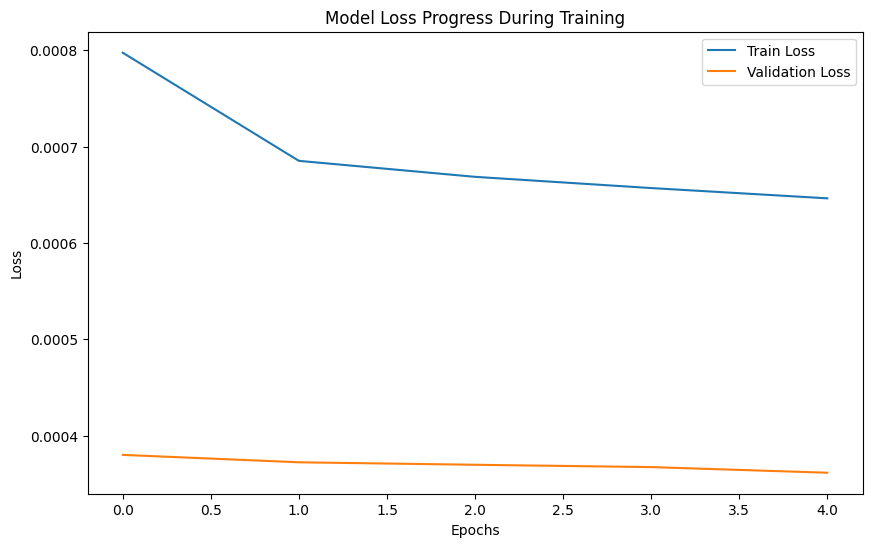

In [8]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=72,
    validation_data=(X_test, y_test),
    verbose=1,
    shuffle=False
)

# Plot training and validation loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MNIST RNN, GRU, and LSTM with PyTorch
## Part 1: Setting Up the Environment
In this section, we define the hyperparameters and configure the training device (CPU/GPU).

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
input_size = 28
sequence_length = 28
hidden_size = 128
num_layers = 2
num_classes = 10
batch_size = 64
num_epochs = 2
learning_rate = 0.001

Using device: cuda


## Part 2: Designing the Neural Network Models
We define three architectures. In each, we take the output of the last time step and pass it through a fully connected layer for classification.

In [21]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

## Part 3: Creating a Custom Dataset Class
First, we download the MNIST CSV files, then we implement the `MnistDataset` class to handle data loading and preprocessing.

In [11]:
# Download MNIST CSV dataset
!wget -O mnist_train.csv https://pjreddie.com/media/files/mnist_train.csv
!wget -O mnist_test.csv https://pjreddie.com/media/files/mnist_test.csv

class MnistDataset(Dataset):
    def __init__(self, file_path):
        # Load data using pandas
        data = pd.read_csv(file_path, header=None)
        # First column is labels, the rest are pixels
        self.y = torch.tensor(data.iloc[:, 0].values, dtype=torch.long)
        # Normalize pixels to [0, 1] and reshape to (Samples, Sequence_Length, Input_Size)
        self.x = torch.tensor(data.iloc[:, 1:].values / 255.0, dtype=torch.float32).reshape(-1, 28, 28)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Create datasets and loaders
train_dataset = MnistDataset('mnist_train.csv')
test_dataset = MnistDataset('mnist_test.csv')

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Data loaded. Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

--2026-06-19 11:28:42--  https://pjreddie.com/media/files/mnist_train.csv
Resolving pjreddie.com (pjreddie.com)... 172.67.185.199, 104.21.88.156, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|172.67.185.199|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/mnist_train.csv [following]
--2026-06-19 11:28:42--  https://data.pjreddie.com/files/mnist_train.csv
Resolving data.pjreddie.com (data.pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109575994 (104M) [text/csv]
Saving to: ‘mnist_train.csv’

mnist_train.csv     100%[===================>] 104.50M   259MB/s    in 0.4s    

2026-06-19 11:28:42 (259 MB/s) - ‘mnist_train.csv’ saved [109575994/109575994]

--2026-06-19 11:28:42--  https://pjreddie.com/media/files/mnist_test.c

## Part 4: Training the Model
We initialize the LSTM model, define the loss function and optimizer, and run the training loop over the specified number of epochs.

In [12]:
import torch.optim as optim
import os
from torch.utils.data import DataLoader

# Re-defining hyperparameters
input_size = 28
sequence_length = 28
hidden_size = 128
num_layers = 2
num_classes = 10
learning_rate = 0.001
num_epochs = 2
batch_size = 64

# Ensure training data is downloaded
if not os.path.exists('mnist_train.csv'):
    print("Downloading mnist_train.csv...")
    os.system('wget -O mnist_train.csv https://data.pjreddie.com/files/mnist_train.csv')

# Ensure data is loaded
train_dataset = MnistDataset('mnist_train.csv')
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

# Initialize the model, loss, and optimizer
model = SimpleLSTM(input_size, hidden_size, num_layers, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
print("Training complete.")

Starting training...
Epoch [1/2], Loss: 0.2214
Epoch [2/2], Loss: 0.0077
Training complete.


## Part 5: Evaluating the Model
We define a function to check accuracy and evaluate the model's performance on the unseen test data.

In [13]:
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            _, predictions = outputs.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train()  # Set back to training mode
    return (float(num_correct) / num_samples) * 100

train_acc = check_accuracy(train_loader, model)
test_acc = check_accuracy(test_loader, model)

print(f"Accuracy on training set: {train_acc:.2f}%")
print(f"Accuracy on test set: {test_acc:.2f}%")

Accuracy on training set: 97.28%
Accuracy on test set: 96.99%


In [14]:
# Final evaluation after retraining
final_test_acc = check_accuracy(test_loader, model)
print(f"Précision finale sur le jeu de test : {final_test_acc:.2f}%")

Précision finale sur le jeu de test : 96.99%


## Part 6: Data Visualization (Sample Images)
Let's visualize a few images from the test set to see the data and the model's predictions.

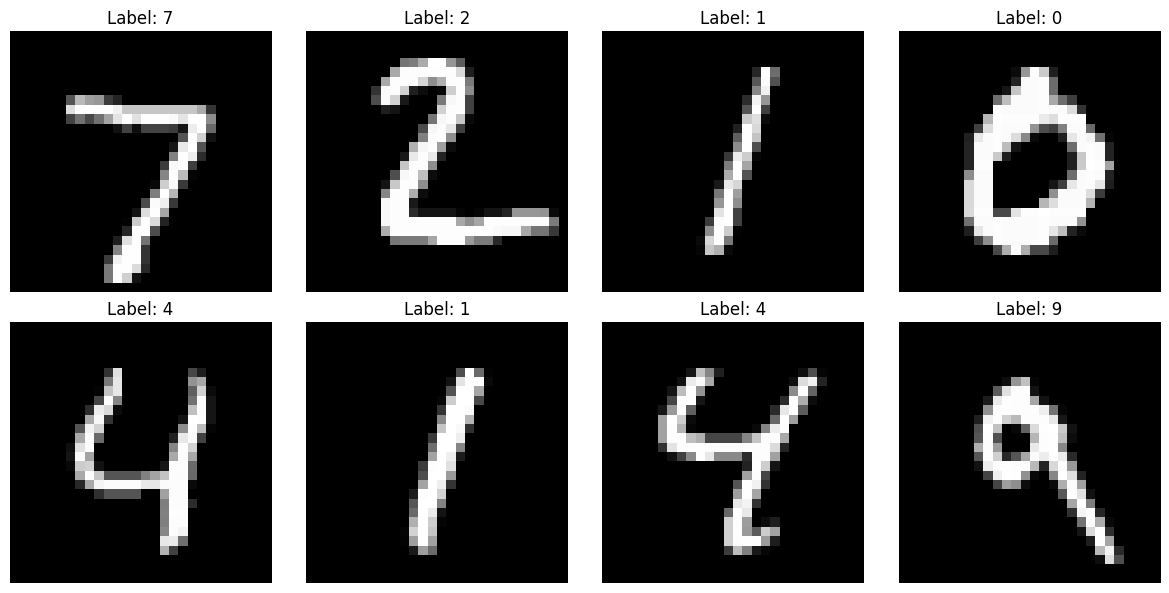

In [15]:
import matplotlib.pyplot as plt

# Get a batch of test data
images, labels = next(iter(test_loader))

# Plot the first 8 images
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Exercices XP Ninja : Prévision du trafic passagers aériens

## Partie 1 : Préparation des données
Dans cette section, nous chargeons les données, gérons les valeurs manquantes et préparons les séquences pour nos modèles récurrents.

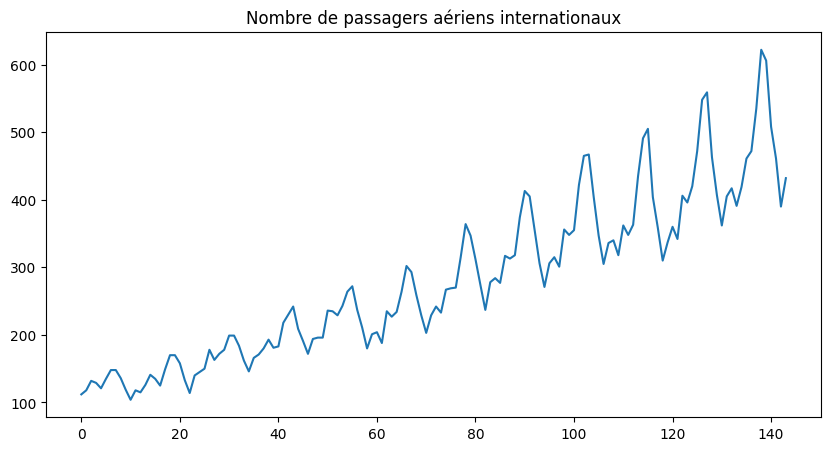

Forme de X_train: (110, 6, 1)
Forme de X_test: (28, 6, 1)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Chargement de l'ensemble de données
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df_air = pd.read_csv(url, usecols=[1])

# 2. Gestion des valeurs manquantes
df_air = df_air.dropna()

# Visualisation rapide
plt.figure(figsize=(10, 5))
plt.plot(df_air)
plt.title('Nombre de passagers aériens internationaux')
plt.show()

# 3. Mise à l'échelle (Scaling)
scaler_air = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler_air.fit_transform(df_air.values)

# 4. Création des séquences (X: 6 mois, y: mois suivant)
def create_airline_sequences(data, look_back=6):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 6
X_air, y_air = create_airline_sequences(data_scaled, look_back)

# Redimensionnement pour l'entrée RNN [samples, time steps, features]
X_air = np.reshape(X_air, (X_air.shape[0], X_air.shape[1], 1))

# Split Train/Test (80% / 20%)
train_size = int(len(X_air) * 0.8)
X_train_air, X_test_air = X_air[:train_size], X_air[train_size:]
y_train_air, y_test_air = y_air[:train_size], y_air[train_size:]

print(f"Forme de X_train: {X_train_air.shape}")
print(f"Forme de X_test: {X_test_air.shape}")

## Partie 2 : Construction de maquettes
Nous allons construire trois modèles à plusieurs couches : un RNN simple, un LSTM et un GRU.

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, Input

def build_model(model_type='LSTM'):
    model = Sequential([
        Input(shape=(look_back, 1))
    ])

    if model_type == 'RNN':
        model.add(SimpleRNN(50, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(SimpleRNN(50))
    elif model_type == 'LSTM':
        model.add(LSTM(50, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(50))
    elif model_type == 'GRU':
        model.add(GRU(50, return_sequences=True))
        model.add(Dropout(0.2))
        model.add(GRU(50))

    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Instanciation des modèles
rnn_model = build_model('RNN')
lstm_model = build_model('LSTM')
gru_model = build_model('GRU')

print("Résumé du modèle RNN Simple:")
rnn_model.summary()
print("\nRésumé du modèle LSTM:")
lstm_model.summary()
print("\nRésumé du modèle GRU:")
gru_model.summary()

Résumé du modèle RNN Simple:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 6, 50)          │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 6, 50)          │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,301 (91.02 KB)

 Trainable params: 23,301 (91.02 KB)

 Non-trainable params: 0 (0.00 B)

## Partie 3 : Formation des modèles
Nous entraînons les trois modèles et utilisons un arrêt précoce (Early Stopping) pour optimiser le temps d'entraînement et éviter le surapprentissage.

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, Input

# 1. Re-chargement et prétraitement des données
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df_air = pd.read_csv(url, usecols=[1]).dropna()
scaler_air = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler_air.fit_transform(df_air.values)

look_back = 6
def create_airline_sequences(data, look_back=6):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

X_air, y_air = create_airline_sequences(data_scaled, look_back)
X_air = np.reshape(X_air, (X_air.shape[0], X_air.shape[1], 1))

train_size = int(len(X_air) * 0.8)
X_train_air, X_test_air = X_air[:train_size], X_air[train_size:]
y_train_air, y_test_air = y_air[:train_size], y_air[train_size:]

# 2. Définition des modèles
def build_ninja_model(model_type='LSTM'):
    model = Sequential([Input(shape=(look_back, 1))])
    if model_type == 'RNN':
        model.add(SimpleRNN(50, return_sequences=True))
        model.add(SimpleRNN(50))
    elif model_type == 'LSTM':
        model.add(LSTM(50, return_sequences=True))
        model.add(LSTM(50))
    elif model_type == 'GRU':
        model.add(GRU(50, return_sequences=True))
        model.add(GRU(50))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

rnn_model = build_ninja_model('RNN')
lstm_model = build_ninja_model('LSTM')
gru_model = build_ninja_model('GRU')

# 3. Entraînement
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Entraînement du modèle RNN Simple...")
history_rnn = rnn_model.fit(X_train_air, y_train_air, epochs=100, batch_size=1, validation_data=(X_test_air, y_test_air), callbacks=[early_stop], verbose=0)

print("Entraînement du modèle LSTM...")
history_lstm = lstm_model.fit(X_train_air, y_train_air, epochs=100, batch_size=1, validation_data=(X_test_air, y_test_air), callbacks=[early_stop], verbose=0)

print("Entraînement du modèle GRU...")
history_gru = gru_model.fit(X_train_air, y_train_air, epochs=100, batch_size=1, validation_data=(X_test_air, y_test_air), callbacks=[early_stop], verbose=0)

print("Entraînement terminé pour tous les modèles.")

Entraînement du modèle RNN Simple...
Entraînement du modèle LSTM...
Entraînement du modèle GRU...
Entraînement terminé pour tous les modèles.


## Partie 4 : Visualisation de l’historique de formation
Nous comparons l'évolution de la perte (MSE) pour les trois modèles.

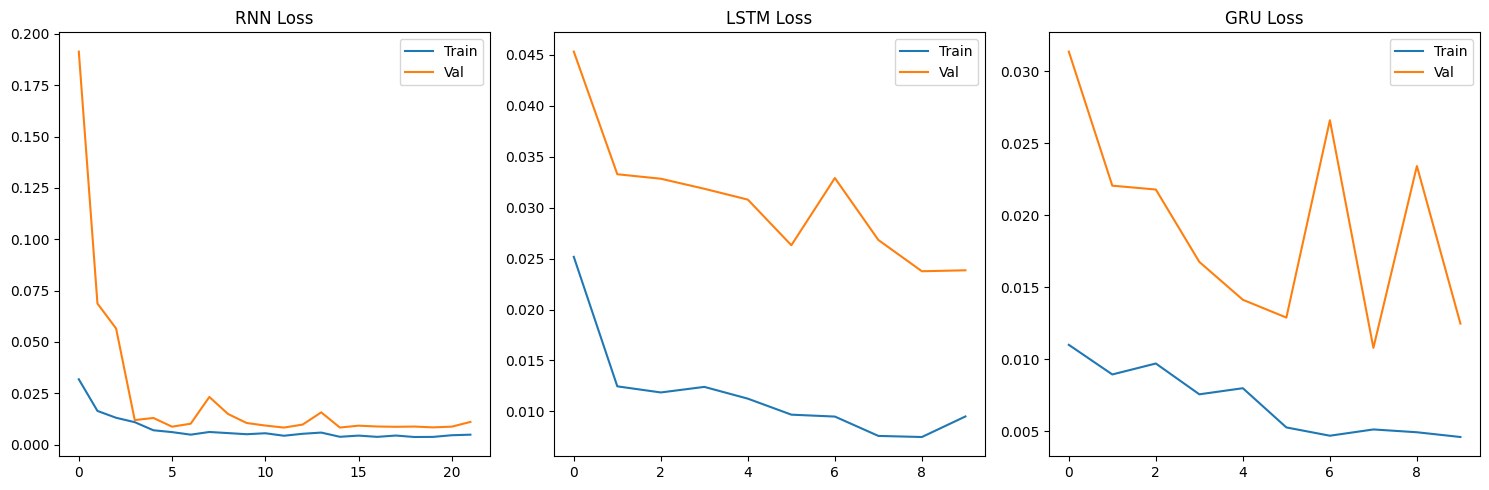

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_rnn.history['loss'], label='Train')
plt.plot(history_rnn.history['val_loss'], label='Val')
plt.title('RNN Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Val')
plt.title('LSTM Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_gru.history['loss'], label='Train')
plt.plot(history_gru.history['val_loss'], label='Val')
plt.title('GRU Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Partie 5 & 6 : Prédictions et Visualisation des résultats
Nous allons maintenant prédire les valeurs sur le jeu de test, inverser la normalisation et comparer graphiquement les résultats.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


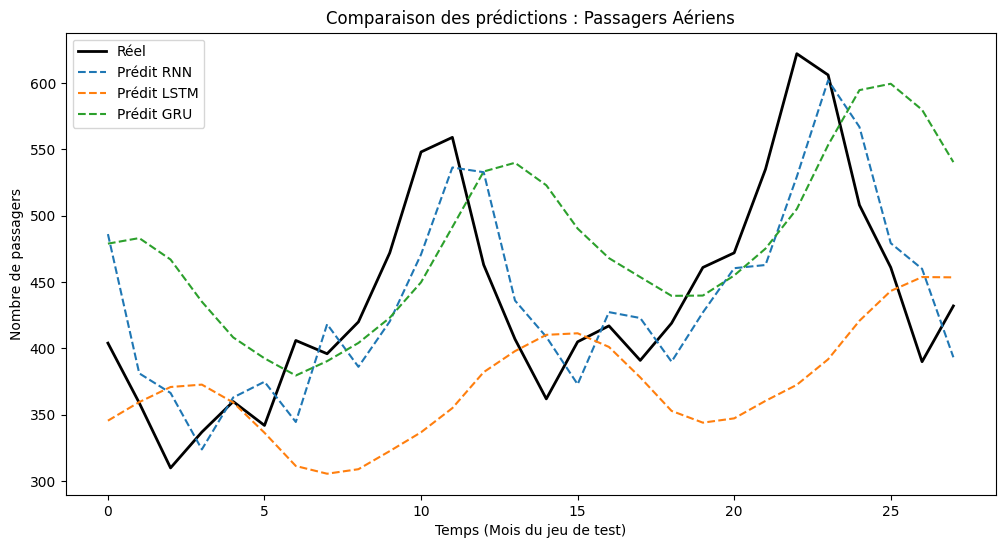

In [20]:
import matplotlib.pyplot as plt

# Faire des prédictions
pred_rnn = rnn_model.predict(X_test_air)
pred_lstm = lstm_model.predict(X_test_air)
pred_gru = gru_model.predict(X_test_air)

# Inverser la transformation
pred_rnn_inv = scaler_air.inverse_transform(pred_rnn)
pred_lstm_inv = scaler_air.inverse_transform(pred_lstm)
pred_gru_inv = scaler_air.inverse_transform(pred_gru)
y_test_inv = scaler_air.inverse_transform(y_test_air.reshape(-1, 1))

# Graphique final
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Réel', color='black', linewidth=2)
plt.plot(pred_rnn_inv, label='Prédit RNN', linestyle='--')
plt.plot(pred_lstm_inv, label='Prédit LSTM', linestyle='--')
plt.plot(pred_gru_inv, label='Prédit GRU', linestyle='--')
plt.title('Comparaison des prédictions : Passagers Aériens')
plt.xlabel('Temps (Mois du jeu de test)')
plt.ylabel('Nombre de passagers')
plt.legend()
plt.show()